In [2]:
import ast
from pathlib import Path 

import cv2 
import dlib
import IPython
import numpy as np
import pandas as pd
import sqlalchemy as db
from retinaface import RetinaFace
from tmdbv3api import Person, TMDb
from icrawler.builtin import GoogleImageCrawler

from qdrant_client import QdrantClient 
from qdrant_client.models import Distance, VectorParams, PointStruct, FieldCondition, Filter, MatchValue, SearchParams

2024-10-21 17:17:05.663242: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [19]:
tmdb = TMDb()
tmdb.api_key = '64a6b6f9419ae4cba5b9a5f1c9e87401'

In [20]:
CLIENT = QdrantClient(host='192.168.0.131', port=6333)   

In [21]:
collections = [x.name for x in CLIENT.get_collections().collections]
if 'Headshots' not in collections:
    CLIENT.recreate_collection(collection_name='Headshots',
                                vectors_config=VectorParams(size=128, distance=Distance.COSINE))

2024-10-20 17:21:13,117 - INFO - httpx - HTTP Request: GET http://192.168.0.131:6333/collections "HTTP/1.1 200 OK"


In [7]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [8]:
def draw_faces(image, faces):
    for face, data in faces.items():
        # バウンディングボックス
        x1, y1, x2, y2 = data['facial_area']
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(image)

In [16]:
def image_from_video(row):
    cap = cv2.VideoCapture(row['filepath'])
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(row['frame_num']))
    ret, frame = cap.read()
    h, w = (row['img_height'], row['img_width'])
    x1, y1, x2, y2 = (row['x1'], row['y1'], row['x2'], row['y2'])
    # x1 = int(row['x1'] * w)
    # y1 = int(row['y1'] * h)
    # x2 = int(row['x2'] * w)
    # y2 = int(row['y2'] * h)
    cv2.rectangle(frame, (x1, y1), 
                         (x2, y2), (0, 0, 255), 3)
    show_image(frame)

In [10]:
def parse_vector(vector):
    return np.array([float(x) for x in vector.split('\n')])

In [26]:
username = 'amos' 
password = 'M0$hicat' 
host = '192.168.0.131' 
port = '3306' 
database = 'CineFace' 

In [27]:
connection_string = f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
engine = db.create_engine(connection_string) 
conn = engine.connect()

In [28]:
episode_id = '63107'
faces_df = pd.read_sql_query(f'SELECT * FROM faces WHERE episode_id = {episode_id}', conn)
faces_df.head()

,episode_id,frame_num,face_num,series_id,season,episode,filename,x1,y1,x2,...,mouth_right_y,mouth_left_x,mouth_left_y,confidence,img_height,img_width,pct_of_frame,distance_from_center,encoding_id,cast_id
0,63107,72,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.345,0.231,0.378,...,0.293,0.363,0.295,0.998,1080,1920,0.27,362.31,3f6e5027-85d1-43e3-b29e-88bff767a47e,None
1,63107,96,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.356,0.241,0.389,...,0.304,0.382,0.305,0.999,1080,1920,0.27,340.18,685d36d3-b580-4f4d-80ac-1a4a0720b3e7,None
2,63107,120,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.422,0.224,0.457,...,0.289,0.448,0.292,0.999,1080,1920,0.31,276.93,5b559591-7442-41c8-b6ca-149db568fbef,None
3,63107,144,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.451,0.194,0.486,...,0.262,0.482,0.262,0.997,1080,1920,0.32,288.52,54a0baa8-e415-4455-80c0-67da4c835793,None
4,63107,168,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.499,0.195,0.535,...,0.269,0.521,0.268,0.994,1080,1920,0.34,279.84,a41d2bcf-da40-456f-a398-8f3a068aeae9,None


## Headshots

In order to match our detected faces to their actors, we first need images of the actors for comparison. We can get a list of all the actors in an episode from our database.

In [12]:
cast = conn.execute(db.text(f'SELECT cast FROM episodes WHERE episode_id = {episode_id}')).fetchone()[0]
cast_ids = cast.split(',')
cast_ids

['16377', '1206', '50807', '15886']

Because only the cast_id is stored, we have to get the name from TMDb.

In [13]:
cast_id = int(cast_ids[2])
person = Person()
details = person.details(cast_id)
details

{'adult': False, 'also_known_as': ['مایکل ریچاردز'], 'biography': "Michael Anthony Richards (born July 24, 1949) is an American actor, comedian, writer and television producer, best known for his portrayal of the eccentric Cosmo Kramer on the television sitcom Seinfeld.\n\nRichards began his career as a stand up comedian, first stepping into a national spotlight when he was featured on Billy Crystal's first cable TV special. He went on to become a series regular on ABC's Fridays. Prior to Seinfeld, he made numerous guest appearances on a variety of television shows including Cheers, Night Court, Miami Vice and St. Elsewhere. His film credits include So I Married an Axe Murderer, Airheads, Young Doctors in Love, Problem Child, Coneheads and UHF. During the run of Seinfeld, he made a guest appearance in Mad About You. After Seinfeld, Richards starred in his own sitcom, The Michael Richards Show, which lasted less than one season.\n\nAfter his series was cancelled, Richards returned to hi

In [14]:
name = details['name']
dst_dir = Path('../data/headshots')
dst = dst_dir.joinpath(name)
crawler = GoogleImageCrawler(storage={'root_dir': str(dst)})
crawler.crawl(keyword=f'{name}', max_num=20)

2024-10-20 13:18:49,309 - INFO - icrawler.crawler - start crawling...
2024-10-20 13:18:49,310 - INFO - icrawler.crawler - starting 1 feeder threads...
2024-10-20 13:18:49,311 - INFO - feeder - thread feeder-001 exit
2024-10-20 13:18:49,311 - INFO - icrawler.crawler - starting 1 parser threads...
2024-10-20 13:18:49,312 - INFO - icrawler.crawler - starting 1 downloader threads...
2024-10-20 13:18:49,905 - INFO - parser - parsing result page https://www.google.com/search?q=Michael+Richards&ijn=0&start=0&tbs=&tbm=isch
2024-10-20 13:18:50,011 - INFO - downloader - skip downloading file 000001.jpg
2024-10-20 13:18:50,011 - INFO - downloader - skip downloading file 000002.jpg
2024-10-20 13:18:50,012 - INFO - downloader - skip downloading file 000003.jpg
2024-10-20 13:18:50,012 - INFO - downloader - skip downloading file 000004.jpg
2024-10-20 13:18:50,013 - INFO - downloader - skip downloading file 000005.jpg
2024-10-20 13:18:50,013 - INFO - downloader - skip downloading file 000006.jpg
2024-

2024-10-20 13:18:52,021 - INFO - parser - downloaded image reached max num, thread parser-001 is ready to exit
2024-10-20 13:18:52,023 - INFO - parser - thread parser-001 exit


This gives us the images we need, but to compare faces, we need to represent the face as a vector. We first have to detect the face in the image; then we must encode the face; finally, we add the encoding to our database.

In [15]:
model_path = '../../data/dlib_face_recognition_resnet_model_v1.dat'
encoder = dlib.face_recognition_model_v1(str(model_path))

2024-10-20 13:18:58.333964: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-10-20 13:18:58.341290: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-10-20 13:18:58.341536: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

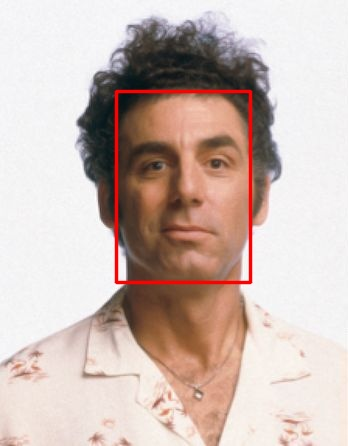

In [16]:
files = [x for x in dst.iterdir()]
img = cv2.imread(str(files[4]))
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)

In [17]:
data = list(faces.values())[0]
x1, y1, x2, y2 = data['facial_area']
face = img[y1:y2, x1:x2]
face = cv2.resize(img, (150, 150))
encoding = encoder.compute_face_descriptor(face)
encoding

dlib.vector([-0.0895363, 0.143651, 0.0178254, -0.0436175, -0.0723353, -0.0447698, -0.0282499, -0.0231762, 0.113417, 0.0599755, 0.245216, 0.0382705, -0.209758, -0.0934722, -0.0288646, 0.105539, -0.157897, -0.0180484, -0.152095, -0.129645, 0.0384384, 0.0239885, 0.0381026, 0.00269124, -0.117068, -0.173188, -0.068627, -0.0798852, 0.0858528, -0.163906, 0.0209421, 0.0663047, -0.222197, -0.10639, 0.0351447, 0.0475752, -0.0208241, -0.0281404, 0.173475, -0.00897682, -0.0803792, 0.0702453, 0.0757027, 0.247878, 0.230707, 0.0227701, -0.04261, -0.0532466, 0.057111, -0.253772, 0.0304965, 0.177667, 0.0886575, 0.133151, 0.0475951, -0.12645, 0.0324499, 0.108704, -0.157737, 0.0241887, 0.0486395, -0.118675, -0.10371, -0.127373, 0.18941, 0.0937726, -0.131325, -0.150948, 0.125806, -0.111799, -0.0547152, 0.114032, -0.0855695, -0.122649, -0.272377, 0.128033, 0.326923, 0.183903, -0.196997, 0.0445659, -0.131828, -0.0322245, -0.0425917, 0.0209759, -0.0793153, -0.0200407, -0.0338238, 0.0501157, 0.128218, -0.0292

Now we put the encoding into our vector database.

In [283]:
CLIENT.upsert(collection_name='Headshots',
              points=[
                  PointStruct(id=0,
                              payload={'cast_id': str(cast_id),
                                       'name': name},
                              vector=np.array(encoding).tolist())
              ])

2024-07-24 16:02:27,117 - INFO - httpx - HTTP Request: PUT http://192.168.0.131:6333/collections/Headshots/points?wait=true "HTTP/1.1 200 OK"


UpdateResult(operation_id=8, status=<UpdateStatus.COMPLETED: 'completed'>)

In [284]:
CLIENT.retrieve(
    collection_name="Headshots",
    ids=[0],
    with_payload=True,
    with_vectors=True
)

2024-07-24 16:02:27,785 - INFO - httpx - HTTP Request: POST http://192.168.0.131:6333/collections/Headshots/points "HTTP/1.1 200 OK"


[Record(id=0, payload={'cast_id': '50807', 'name': 'Michael Richards'}, vector=[-0.06799609, 0.10909194, 0.013537051, -0.033124175, -0.05493322, -0.033999316, -0.02145368, -0.017600572, 0.08613161, 0.045546908, 0.18622294, 0.029063528, -0.15929544, -0.07098511, -0.02192046, 0.08014892, -0.11991094, -0.0137064, -0.11550482, -0.09845564, 0.029191071, 0.01821745, 0.028936047, 0.0020437946, -0.0889042, -0.13152295, -0.05211702, -0.060666762, 0.06519878, -0.12447404, 0.015903948, 0.050353434, -0.1687417, -0.080794975, 0.026689736, 0.03612975, -0.015814364, -0.021370485, 0.13174143, -0.0068172184, -0.06104194, 0.053345993, 0.05749047, 0.18824449, 0.17520425, 0.017292215, -0.032359056, -0.040436823, 0.043371513, -0.192721, 0.023159826, 0.13492468, 0.067328684, 0.101118036, 0.03614493, -0.096029304, 0.024643261, 0.08255224, -0.11978943, 0.018369514, 0.036938004, -0.09012458, -0.07876015, -0.09673035, 0.14384268, 0.07121321, -0.09973133, -0.11463358, 0.09554051, -0.08490301, -0.041552044, 0.086

The matching can conceivable be done either way, from face to headshot or headshot to face.

In [292]:
results = CLIENT.search(
    collection_name='FacialEmbeddings',
    query_filter=Filter(
        must=[
            FieldCondition(
                key='episode_id',
                match=MatchValue(value=episode_id)
            )
        ],
    ),
    search_params=SearchParams(hnsw_ef=128, exact=True),
    query_vector=np.array(encoding).tolist(),
    limit=100
)

2024-07-24 16:06:17,095 - INFO - httpx - HTTP Request: POST http://192.168.0.131:6333/collections/FacialEmbeddings/points/search "HTTP/1.1 200 OK"


In [293]:
results

[ScoredPoint(id='82124276-9515-4469-9e34-0e1e1a1b1c28', version=677398, score=0.9619696, payload={'episode': '4', 'episode_id': '63107', 'face_num': '1', 'filepath': '/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEBRip.x265-RARBG/Seinfeld.S01.1080p.WEBRip.x265-RARBG/Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4', 'frame_num': '20256', 'season': '1', 'series_id': '98904'}, vector=None, shard_key=None),
 ScoredPoint(id='ecfd6d10-c876-40fd-aed9-e0bf309a8b50', version=2215932, score=0.9619696, payload={'episode': '4', 'episode_id': '63107', 'face_num': '1', 'filepath': '/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEBRip.x265-RARBG/Seinfeld.S01.1080p.WEBRip.x265-RARBG/Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4', 'frame_num': '20256', 'season': '1', 'series_id': '98904'}, vector=None, shard_key=None),
 ScoredPoint(id='d1c20aeb-28ce-4d54-95f4-79219e34e6c8', version=2215467, score=0.9614082, payload={'episode': '4', 'episode_id': '63107', 'face_num': '0', 'filepath': '/home/amos/media/tv/Seinfeld.

In [31]:
result_df = pd.DataFrame([dict(x.payload) for x in results], index=[x.id for x in results])
result_df['score'] = [x.score for x in results]
result_df['episode_id'] = result_df['episode_id'].astype(int)
result_df['frame_num'] = result_df['frame_num'].astype(int)
result_df['face_num'] = result_df['face_num'].astype(int)
result_df.head()

NameError: name 'results' is not defined

In [30]:
temp = pd.read_sql_query(f"""
                       SELECT * 
                       FROM faces 
                       WHERE episode_id = {result_df.iloc[0]['episode_id']}
                       """, conn)
temp.head()

NameError: name 'result_df' is not defined

In [296]:
df = result_df.merge(temp[['x1', 'y1', 'x2', 'y2', 'img_height', 'img_width', 'episode_id', 'frame_num', 'face_num']],
                     on=['episode_id', 'frame_num', 'face_num'],
                     how='inner')
df = df.drop_duplicates()
df = df.sort_values('score', ascending=False)
df.head()

,episode,episode_id,face_num,filepath,frame_num,season,series_id,score,x1,y1,x2,y2,img_height,img_width
0,4,63107,1,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,20256,1,98904,0.961970,0.180,0.038,0.277,0.237,1080,1920
2,4,63107,0,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,15288,1,98904,0.961408,0.608,0.250,0.677,0.459,1080,1920
4,4,63107,0,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,30312,1,98904,0.959928,0.036,0.164,0.156,0.522,1080,1920
6,4,63107,2,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,30600,1,98904,0.958895,0.782,0.100,0.855,0.371,1080,1920
8,4,63107,2,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,30960,1,98904,0.958199,0.709,0.083,0.798,0.417,1080,1920


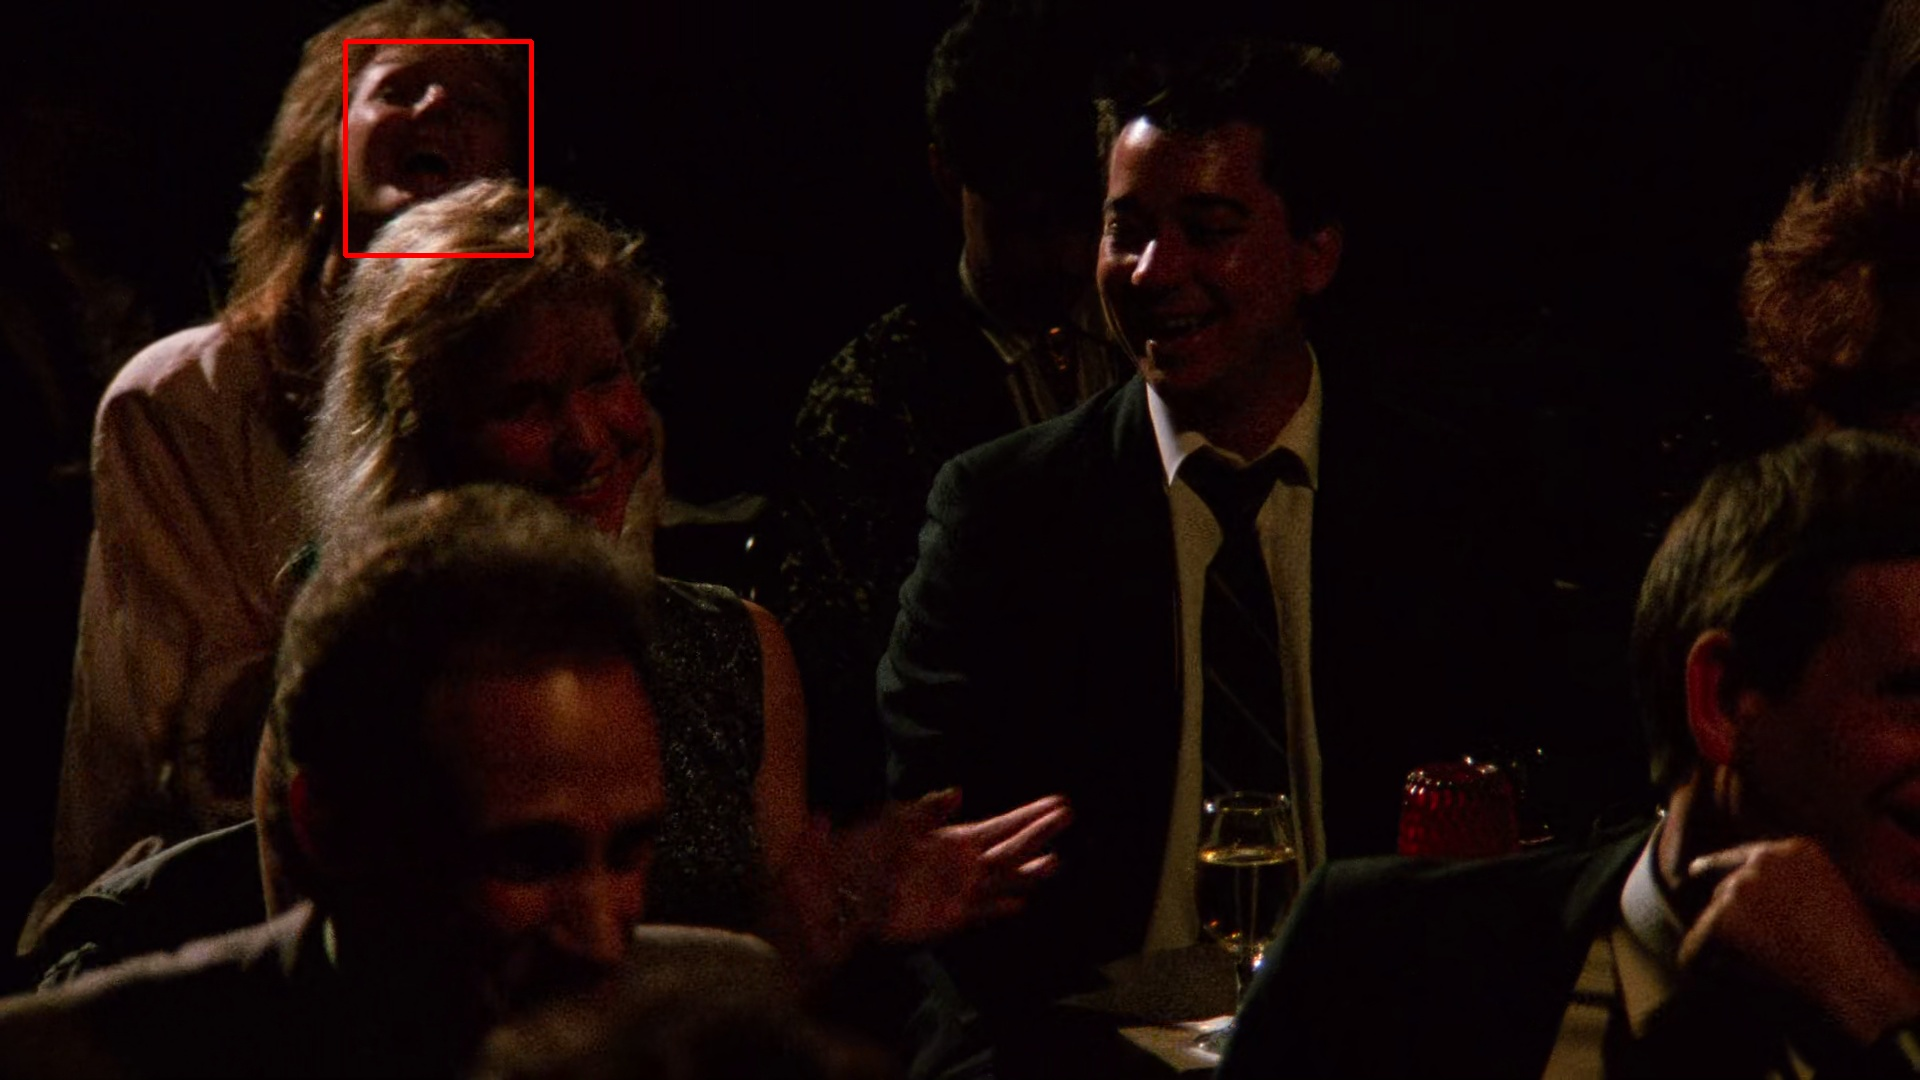

In [297]:
row = df.iloc[0]
image_from_video(row)
# for i in range(0, 25):
#     row = df.iloc[i]
#     image_from_video(row)

This method doesn't work at all. We may need to cluster first.

## Clustering

In [61]:
# episode_df = pd.read_sql_query(f"""
#                        SELECT * 
#                        FROM faces 
#                        WHERE episode_id = 63107
#                        """, conn)
episode_df = pd.read_csv('/home/amos/programs/CineFace/data/faces/seinfeld_1989_98904/Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.csv', index_col=0)
episode_df['encoding'] = episode_df['encoding'].map(lambda x: [float(i) for i in x.split('\n')])
episode_df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,img_height,filepath,encoding,series_id,episode_id,filename,distance_from_center,pct_of_frame,season,episode
0,0.345,0.231,0.378,0.315,0.351,0.262,0.365,0.265,0.355,0.280,...,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,"[-0.101329, 0.0118607, 0.0249915, 0.0144159, -...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,362.31,0.27,1,4
1,0.356,0.241,0.389,0.323,0.376,0.275,0.385,0.275,0.385,0.292,...,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,"[-0.0620513, 0.048339, 0.0519431, -0.0228687, ...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,340.18,0.27,1,4
2,0.422,0.224,0.457,0.312,0.440,0.258,0.453,0.260,0.449,0.277,...,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,"[-0.122035, 0.0537157, 0.0832252, -0.0692148, ...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,276.93,0.31,1,4
3,0.451,0.194,0.486,0.285,0.468,0.229,0.481,0.228,0.480,0.242,...,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,"[-0.0894812, 0.0988888, 0.115139, -0.0414661, ...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,288.52,0.32,1,4
4,0.499,0.195,0.535,0.291,0.505,0.235,0.521,0.233,0.511,0.253,...,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,"[-0.113836, 0.0537113, -0.00212441, 0.0128548,...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,279.84,0.34,1,4


In [60]:
encoding = episode_df.iloc[0]['encoding']
dlib.vector([float(x) for x in encoding.split('\n')])

dlib.vector([-0.101329, 0.0118607, 0.0249915, 0.0144159, -0.110906, -0.0452482, 0.0228434, -0.115191, 0.0948691, -0.0419382, 0.186416, 0.025433, -0.249325, -0.144182, -0.0139814, 0.0777174, -0.110742, -0.102061, -0.128178, -0.165764, 0.010182, 0.0464676, 0.0418372, -0.00810026, -0.185343, -0.183411, -0.107704, -0.0889683, 0.0326769, -0.0840122, 0.0963781, 0.0773951, -0.241828, -0.0736096, 0.0145904, 0.0767443, -0.0431666, -0.0421465, 0.172895, -0.0562589, -0.127386, 0.0704186, 0.0430399, 0.268986, 0.191005, -0.0523739, 0.00475462, -0.0753513, 0.139731, -0.223954, 0.037773, 0.178202, 0.131247, 0.0836699, 0.0283722, -0.0778028, 0.0745376, 0.219663, -0.198795, 0.10203, 0.0581502, -0.107165, -0.0479439, -0.035691, 0.103117, 0.0452389, -0.117189, -0.185107, 0.171883, -0.189442, -0.055343, 0.190174, -0.130169, -0.186403, -0.333733, 0.0734798, 0.505246, 0.150763, -0.195497, -0.0161214, -0.119512, 0.000428203, 0.0379528, 0.07439, -0.0305811, -0.104318, -0.132483, 0.0658331, 0.203277, -0.002374

In [49]:
encoding_results = CLIENT.retrieve(collection_name='FacialEmbeddings',
                             ids=episode_df['encoding_id'].tolist(),
                             with_vectors=True)
print(len(encoding_results))
encoding_results[0]

KeyError: 'encoding_id'

In [42]:
encoding_df = pd.DataFrame([x.payload for x in encoding_results])
encoding_df['episode_id'] = encoding_df['episode_id'].astype(int)
encoding_df['frame_num'] = encoding_df['frame_num'].astype(int)
encoding_df['face_num'] = encoding_df['face_num'].astype(int)
encoding_df['encoding'] = [x.vector for x in encoding_results]
encoding_df.head()

,episode,episode_id,face_num,filepath,frame_num,season,series_id,encoding
0,4,63107,0,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,3936,1,98904,"[-0.085105576, 0.042636614, 0.08370825, -0.029..."
1,4,63107,2,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,30696,1,98904,"[-0.008063362, 0.06838547, 0.038686916, 0.0029..."
2,4,63107,2,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,16704,1,98904,"[-0.118555814, 0.0347825, 0.053929046, -0.0035..."
3,4,63107,1,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,19632,1,98904,"[-0.094814785, 0.022338606, 0.053714264, -0.03..."
4,4,63107,0,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...,28008,1,98904,"[-0.05334254, 0.06460357, 0.033916157, -0.0456..."


In [43]:
episode_df = episode_df.merge(encoding_df[['episode_id', 'frame_num', 'face_num', 'encoding', 'filepath']],
                  on=['episode_id', 'frame_num', 'face_num'],
                  how='inner')
episode_df.head()

,episode_id,frame_num,face_num,series_id,season,episode,filename,x1,y1,x2,...,mouth_left_y,confidence,img_height,img_width,pct_of_frame,distance_from_center,encoding_id,cast_id,encoding,filepath
0,63107,72,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.345,0.231,0.378,...,0.295,0.998,1080,1920,0.27,362.31,3f6e5027-85d1-43e3-b29e-88bff767a47e,None,"[-0.07000026, 0.008193628, 0.017264668, 0.0099...",/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...
1,63107,96,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.356,0.241,0.389,...,0.305,0.999,1080,1920,0.27,340.18,685d36d3-b580-4f4d-80ac-1a4a0720b3e7,None,"[-0.04520568, 0.03521598, 0.03784164, -0.01666...",/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...
2,63107,120,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.422,0.224,0.457,...,0.292,0.999,1080,1920,0.31,276.93,5b559591-7442-41c8-b6ca-149db568fbef,None,"[-0.08379567, 0.036884032, 0.05714681, -0.0475...",/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...
3,63107,144,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.451,0.194,0.486,...,0.262,0.997,1080,1920,0.32,288.52,54a0baa8-e415-4455-80c0-67da4c835793,None,"[-0.06020688, 0.066536725, 0.07747057, -0.0279...",/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...
4,63107,168,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.499,0.195,0.535,...,0.268,0.994,1080,1920,0.34,279.84,a41d2bcf-da40-456f-a398-8f3a068aeae9,None,"[-0.07954493, 0.03753173, -0.0014844693, 0.008...",/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...


In [75]:
def chinese_whisper(df):
    encodings = [dlib.vector(x) for x in df['encoding']]
    labels = dlib.chinese_whispers_clustering(encodings, 0.45)
    df = df.assign(label=labels)
    g = df[['label', 'filepath']].groupby('label').count()
    top = g[g['filepath'] > 5]
    df = df.merge(top.rename({'filepath': 'count'}, axis=1),
                  how='left',
                  left_on='label',
                  right_index=True)
    return df

In [76]:
episode_clustered = chinese_whisper(episode_df)
print(episode_clustered['label'].nunique())
episode_clustered.head()

12


,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,encoding,series_id,episode_id,filename,distance_from_center,pct_of_frame,season,episode,label,count
0,0.345,0.231,0.378,0.315,0.351,0.262,0.365,0.265,0.355,0.280,...,"[-0.101329, 0.0118607, 0.0249915, 0.0144159, -...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,362.31,0.27,1,4,0,1841.0
1,0.356,0.241,0.389,0.323,0.376,0.275,0.385,0.275,0.385,0.292,...,"[-0.0620513, 0.048339, 0.0519431, -0.0228687, ...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,340.18,0.27,1,4,0,1841.0
2,0.422,0.224,0.457,0.312,0.440,0.258,0.453,0.260,0.449,0.277,...,"[-0.122035, 0.0537157, 0.0832252, -0.0692148, ...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,276.93,0.31,1,4,0,1841.0
3,0.451,0.194,0.486,0.285,0.468,0.229,0.481,0.228,0.480,0.242,...,"[-0.0894812, 0.0988888, 0.115139, -0.0414661, ...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,288.52,0.32,1,4,0,1841.0
4,0.499,0.195,0.535,0.291,0.505,0.235,0.521,0.233,0.511,0.253,...,"[-0.113836, 0.0537113, -0.00212441, 0.0128548,...",98904,NaN,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,279.84,0.34,1,4,0,1841.0


In [78]:
episode_clustered.to_csv('../../data/clustered.csv')

In [32]:
df = pd.read_sql_query('SELECT * FROM faces WHERE episode_id = 63107', conn)
df.head()

,episode_id,frame_num,face_num,series_id,season,episode,filename,x1,y1,x2,...,mouth_right_y,mouth_left_x,mouth_left_y,confidence,img_height,img_width,pct_of_frame,distance_from_center,encoding_id,cast_id
0,63107,72,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.345,0.231,0.378,...,0.293,0.363,0.295,0.998,1080,1920,0.27,362.31,3f6e5027-85d1-43e3-b29e-88bff767a47e,None
1,63107,96,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.356,0.241,0.389,...,0.304,0.382,0.305,0.999,1080,1920,0.27,340.18,685d36d3-b580-4f4d-80ac-1a4a0720b3e7,None
2,63107,120,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.422,0.224,0.457,...,0.289,0.448,0.292,0.999,1080,1920,0.31,276.93,5b559591-7442-41c8-b6ca-149db568fbef,None
3,63107,144,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.451,0.194,0.486,...,0.262,0.482,0.262,0.997,1080,1920,0.32,288.52,54a0baa8-e415-4455-80c0-67da4c835793,None
4,63107,168,0,98904,1,4,Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4,0.499,0.195,0.535,...,0.269,0.521,0.268,0.994,1080,1920,0.34,279.84,a41d2bcf-da40-456f-a398-8f3a068aeae9,None


In [35]:
cast = conn.execute(db.text('SELECT cast FROM episodes WHERE episode_id = 63107')).fetchone()[0]
cast_ids = cast.split(',')
cast_ids

['16377', '1206', '50807', '15886']

In [37]:
headshots = pd.read_sql_query(f'SELECT * FROM headshots WHERE cast_id IN ({",".join(cast_ids)})', conn)
headshots

,cast_id,headshot_id,name,x1,y1,x2,y2,img_height,img_width,pct_of_frame
0,16377,e43122b7-f95d-4821-ba91-6f7baa469b96,Jerry Seinfeld,0.206,0.156,0.781,0.758,1080,1440,0.347
1,16377,bba489e4-7493-49e3-8e8d-d7a00210a97a,Jerry Seinfeld,0.221,0.146,0.785,0.716,1122,1600,0.322
2,16377,0f927f19-34f6-47a4-b7b8-4f2fb79b40fe,Jerry Seinfeld,0.224,0.172,0.733,0.732,450,600,0.285
3,16377,ad3aff4b-492d-469d-bdcf-6f7d94d57970,Jerry Seinfeld,0.272,0.148,0.718,0.588,936,1410,0.196
4,16377,e9f6de01-6994-4137-a294-378dc88ac20c,Jerry Seinfeld,0.379,0.139,0.616,0.685,800,527,0.130
5,1206,498367ff-e05b-4d04-a146-4fa680461c9c,Jason Alexander,0.233,0.173,0.770,0.930,300,300,0.406
6,1206,7564f18b-6c6f-44d9-9bea-ccacd6f4d95a,Jason Alexander,0.220,0.146,0.826,0.767,1080,1440,0.376
7,1206,f817ffc9-f4ee-49ea-93a9-9359c091770f,Jason Alexander,0.214,0.229,0.799,0.809,597,785,0.339
8,1206,e76eb0bb-563c-4939-bac0-cde428eba2a5,Jason Alexander,0.267,0.116,0.679,0.935,900,611,0.337
9,1206,7d305b36-5ae9-4af4-9a8b-4f575ac037d1,Jason Alexander,0.238,0.145,0.788,0.700,307,400,0.306


In [80]:
encoding = episode_df.iloc[0]['encoding']
encoding

[-0.101329,
 0.0118607,
 0.0249915,
 0.0144159,
 -0.110906,
 -0.0452482,
 0.0228434,
 -0.115191,
 0.0948691,
 -0.0419382,
 0.186416,
 0.025433,
 -0.249325,
 -0.144182,
 -0.0139814,
 0.0777174,
 -0.110742,
 -0.102061,
 -0.128178,
 -0.165764,
 0.010182,
 0.0464676,
 0.0418372,
 -0.00810026,
 -0.185343,
 -0.183411,
 -0.107704,
 -0.0889683,
 0.0326769,
 -0.0840122,
 0.0963781,
 0.0773951,
 -0.241828,
 -0.0736096,
 0.0145904,
 0.0767443,
 -0.0431666,
 -0.0421465,
 0.172895,
 -0.0562589,
 -0.127386,
 0.0704186,
 0.0430399,
 0.268986,
 0.191005,
 -0.0523739,
 0.00475462,
 -0.0753513,
 0.139731,
 -0.223954,
 0.037773,
 0.178202,
 0.131247,
 0.0836699,
 0.0283722,
 -0.0778028,
 0.0745376,
 0.219663,
 -0.198795,
 0.10203,
 0.0581502,
 -0.107165,
 -0.0479439,
 -0.035691,
 0.103117,
 0.0452389,
 -0.117189,
 -0.185107,
 0.171883,
 -0.189442,
 -0.055343,
 0.190174,
 -0.130169,
 -0.186403,
 -0.333733,
 0.0734798,
 0.505246,
 0.150763,
 -0.195497,
 -0.0161214,
 -0.119512,
 0.000428203,
 0.0379528,
 0.

In [90]:
filename = episode_df.iloc[0]['filepath']
print(filename)
cap = cv2.VideoCapture(filename)

/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEBRip.x265-RARBG/Seinfeld.S01.1080p.WEBRip.x265-RARBG/Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4


In [91]:
cap.set(cv2.CAP_PROP_POS_FRAMES, episode_df.iloc[0]['frame_num'])

True

In [92]:
ret, frame = cap.read()

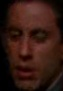

In [96]:
row = episode_df.iloc[0]
x1 = int(row['x1'] * row['img_width'])
y1 = int(row['y1'] * row['img_height'])
x2 = int(row['x2'] * row['img_width'])
y2 = int(row['y2'] * row['img_height'])
face = frame[y1:y2, x1:x2, :]
show_image(face)

In [14]:
model_path = '../../data/dlib_face_recognition_resnet_model_v1.dat'
ENCODER = dlib.face_recognition_model_v1(str(model_path))

In [100]:
resized = cv2.resize(face, (150, 150))
e = ENCODER.compute_face_descriptor(resized)
e

dlib.vector([-0.0850287, 0.0154704, 0.033522, 0.0182814, -0.120032, -0.038814, 0.00942304, -0.121328, 0.0935423, -0.0468204, 0.18437, 0.0148436, -0.247303, -0.142568, -0.0216013, 0.0857728, -0.102639, -0.123586, -0.105085, -0.150865, 0.0186406, 0.0604448, 0.0416965, -0.00183143, -0.199941, -0.193234, -0.122885, -0.0951837, 0.0362195, -0.0877885, 0.0873014, 0.0720308, -0.250907, -0.0714292, 0.0218155, 0.065345, -0.0248585, -0.0509528, 0.177151, -0.0283218, -0.133907, 0.0623757, 0.0383182, 0.264757, 0.194616, -0.0537864, 0.0152283, -0.071322, 0.121293, -0.217497, 0.0316681, 0.179133, 0.139697, 0.0875719, 0.0188592, -0.0693579, 0.0787233, 0.215048, -0.209225, 0.104183, 0.0532727, -0.098309, -0.0321318, -0.00573229, 0.116424, 0.0388626, -0.100762, -0.19188, 0.188114, -0.196714, -0.0664087, 0.192861, -0.135974, -0.174004, -0.334629, 0.0627797, 0.51015, 0.140894, -0.207779, -0.00983082, -0.112299, 0.0047687, 0.0394895, 0.0715295, -0.0194601, -0.106064, -0.129371, 0.065651, 0.224228, -0.00550

In [102]:
dlib.vector(encoding)

dlib.vector([-0.101329, 0.0118607, 0.0249915, 0.0144159, -0.110906, -0.0452482, 0.0228434, -0.115191, 0.0948691, -0.0419382, 0.186416, 0.025433, -0.249325, -0.144182, -0.0139814, 0.0777174, -0.110742, -0.102061, -0.128178, -0.165764, 0.010182, 0.0464676, 0.0418372, -0.00810026, -0.185343, -0.183411, -0.107704, -0.0889683, 0.0326769, -0.0840122, 0.0963781, 0.0773951, -0.241828, -0.0736096, 0.0145904, 0.0767443, -0.0431666, -0.0421465, 0.172895, -0.0562589, -0.127386, 0.0704186, 0.0430399, 0.268986, 0.191005, -0.0523739, 0.00475462, -0.0753513, 0.139731, -0.223954, 0.037773, 0.178202, 0.131247, 0.0836699, 0.0283722, -0.0778028, 0.0745376, 0.219663, -0.198795, 0.10203, 0.0581502, -0.107165, -0.0479439, -0.035691, 0.103117, 0.0452389, -0.117189, -0.185107, 0.171883, -0.189442, -0.055343, 0.190174, -0.130169, -0.186403, -0.333733, 0.0734798, 0.505246, 0.150763, -0.195497, -0.0161214, -0.119512, 0.000428203, 0.0379528, 0.07439, -0.0305811, -0.104318, -0.132483, 0.0658331, 0.203277, -0.002374

## Testing

In [13]:
# df = pd.read_csv('../../data/seinfeld_find_faces_queue_single.csv', index_col=0)
df = pd.read_csv('../../data/seinfeld_find_faces_dev.csv', index_col=0)
# df = pd.read_csv('../../data/fixed.csv', index_col=0)
# df = pd.read_csv('../../data/seinfeld.csv', index_col=0)
# df = pd.read_csv('/home/amos/programs/CineFace/data/faces/seinfeld_1989_98904/Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.csv', index_col=0)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,mouth_right_y,mouth_left_x,mouth_left_y,confidence,frame_num,face_num,encoding,img_width,img_height,filepath
0,664,247,725,340,673,285,700,287,681,303,...,319,696,321,0.998,72,0,[-8.07232633e-02 5.08920997e-02 3.17381881e-...,1920,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...
1,685,261,745,351,722,297,738,297,739,315,...,329,730,330,0.999,96,0,[-0.08707178 0.05739465 0.09491231 -0.043649...,1920,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...
2,812,241,876,337,849,278,868,281,865,299,...,312,858,315,0.999,120,0,[-0.09564364 0.06066579 0.1017349 -0.043244...,1920,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...
3,866,206,932,308,897,246,923,244,921,260,...,282,924,281,1.000,144,0,[-0.08593325 0.10685313 0.14113067 -0.054531...,1920,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...
4,960,210,1026,314,970,253,999,252,980,273,...,291,998,290,0.998,168,0,[-0.10320125 0.05980013 0.02474546 0.002192...,1920,1080,/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEB...


In [187]:
filename = df.iloc[0]['filepath']
print(filename)
cap = cv2.VideoCapture(filename)


/home/amos/media/tv/Seinfeld.S01-S09.1080p.WEBRip.x265-RARBG/Seinfeld.S01.1080p.WEBRip.x265-RARBG/Seinfeld.S01E04.1080p.WEBRip.x265-RARBG.mp4


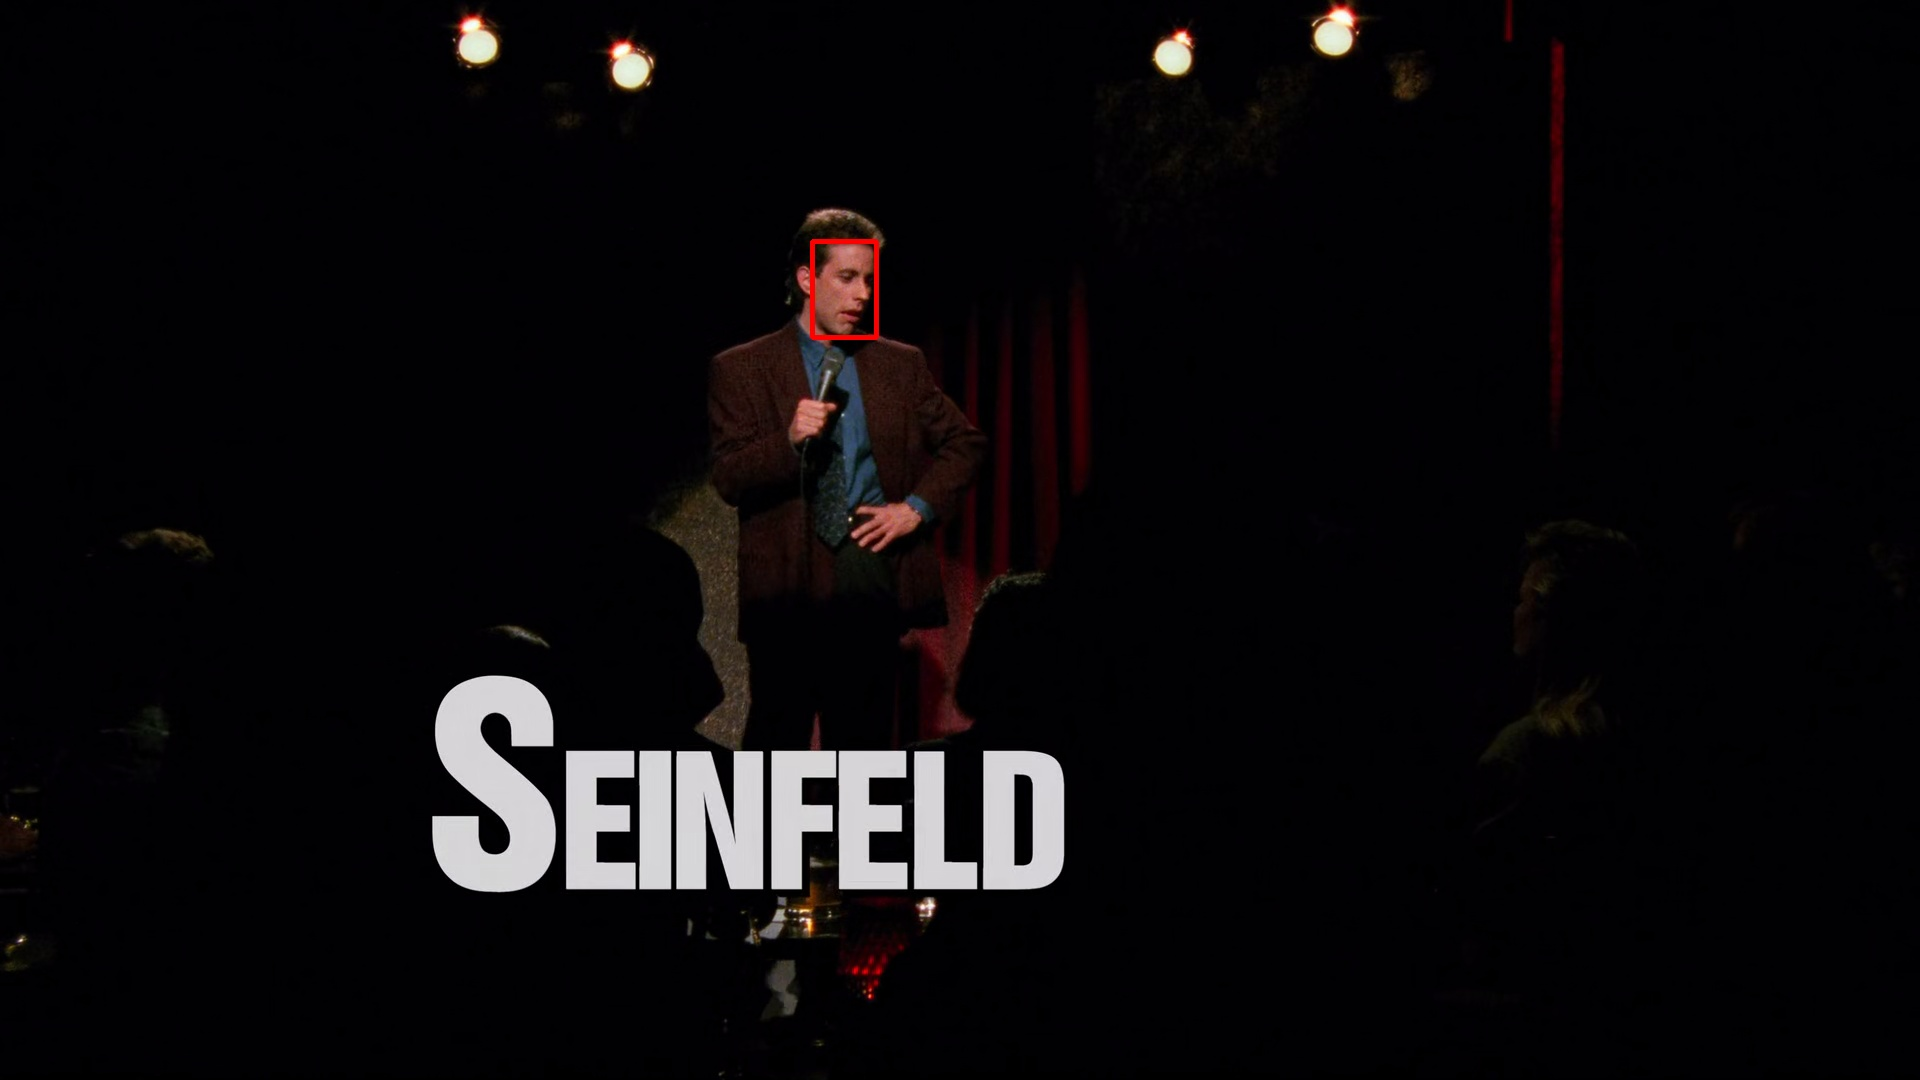

In [22]:
row = df[(df['frame_num'] == 120) &
         (df['face_num'] == 0)]
image_from_video(row.iloc[0])

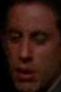

In [188]:
row = df.iloc[0]
cap.set(cv2.CAP_PROP_POS_FRAMES, row['frame_num'])
ret, frame = cap.read()
# x1 = row['x1']
# y1 = row['y1']
# x2 = row['x2']
# y2 = row['y2']
x1 = int(row['x1'] * row['img_width'])
y1 = int(row['y1'] * row['img_height'])
x2 = int(row['x2'] * row['img_width'])
y2 = int(row['y2'] * row['img_height'])
face = frame[y1:y2, x1:x2]
show_image(face)

In [189]:
rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
resized = cv2.resize(rgb, (150, 150), interpolation=cv2.INTER_AREA)
e = ENCODER.compute_face_descriptor(resized)
e

dlib.vector([-0.129574, 0.0661117, 0.0377044, -0.00579443, -0.109991, -0.00326925, 0.0156142, -0.0927216, 0.0835441, -0.0166531, 0.236632, -0.00626456, -0.296815, -0.120714, 0.0203223, 0.0688599, -0.136713, -0.106784, -0.172407, -0.146828, 0.0118537, 0.011166, 0.0157074, -0.00469572, -0.159003, -0.248022, -0.0726195, -0.124463, 0.0662539, -0.133419, 0.114416, 0.0580246, -0.211194, -0.0694184, 0.00754317, 0.0675721, -0.0459311, -0.0773862, 0.195068, -0.113819, -0.154197, 0.00826573, 0.0393167, 0.271514, 0.177895, -0.0421906, 0.00457022, -0.0541102, 0.171928, -0.248806, 0.0610242, 0.186428, 0.157164, 0.0959734, 0.0585466, -0.115462, 0.0852179, 0.206918, -0.208537, 0.102927, 0.0780469, -0.124528, -0.0729929, -0.0867967, 0.118939, 0.0747486, -0.121847, -0.206467, 0.158559, -0.158291, -0.0605222, 0.176501, -0.149502, -0.195174, -0.307092, 0.0779876, 0.482523, 0.154508, -0.246486, -0.0311669, -0.091356, -0.00664173, 0.0544844, 0.0873072, -0.0454468, -0.106941, -0.129781, 0.0418237, 0.194348,

In [190]:
# encoding = dlib.vector([float(x.strip()) for x in row['encoding'][1:-2].split(' ') if x])
encoding = dlib.vector([float(x) for x in row['encoding'].split('\n')])
encoding

dlib.vector([-0.103766, 0.0299908, 0.027249, 0.0222682, -0.135834, -0.0266622, 0.0115646, -0.107253, 0.0843649, -0.0281556, 0.212529, 0.0154715, -0.245568, -0.134947, 0.00905476, 0.0798302, -0.120685, -0.143014, -0.12428, -0.142173, 0.00714231, 0.0318652, 0.00752137, 0.00831104, -0.158663, -0.215682, -0.10165, -0.106638, 0.0612469, -0.109857, 0.0787274, 0.0865797, -0.21338, -0.0831706, 0.0357321, 0.101214, -0.0339809, -0.0729463, 0.17485, -0.0848972, -0.150605, 0.0528627, 0.0567758, 0.283786, 0.195355, -0.0418658, 0.00273437, -0.0446004, 0.129349, -0.213918, 0.0698098, 0.19089, 0.153242, 0.10303, 0.0107294, -0.101071, 0.0550767, 0.229985, -0.21864, 0.0954119, 0.0816039, -0.109319, -0.0497111, -0.0761482, 0.116398, 0.0725105, -0.132131, -0.213264, 0.133407, -0.196862, -0.0926317, 0.170389, -0.16618, -0.181949, -0.320161, 0.0899132, 0.505303, 0.159304, -0.198764, -0.0223511, -0.0814615, -0.0168392, 0.022117, 0.0925297, -0.0191644, -0.105239, -0.126115, 0.0506159, 0.191911, 0.0178528, -0.

In [191]:
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances

In [192]:
similarity = cosine_similarity(np.array(e).reshape(-1, 1), np.array(encoding).reshape(-1, 1))
similarity

array([[ 1., -1., -1., ...,  1., -1., -1.],
       [-1.,  1.,  1., ..., -1.,  1.,  1.],
       [-1.,  1.,  1., ..., -1.,  1.,  1.],
       ...,
       [ 1., -1., -1., ...,  1., -1., -1.],
       [-1.,  1.,  1., ..., -1.,  1.,  1.],
       [-1.,  1.,  1., ..., -1.,  1.,  1.]])

In [193]:
distance = cosine_distances(np.array(e).reshape(-1, 1), np.array(encoding).reshape(-1, 1))
print(distance)

[[0. 2. 2. ... 0. 2. 2.]
 [2. 0. 0. ... 2. 0. 0.]
 [2. 0. 0. ... 2. 0. 0.]
 ...
 [0. 2. 2. ... 0. 2. 2.]
 [2. 0. 0. ... 2. 0. 0.]
 [2. 0. 0. ... 2. 0. 0.]]


In [194]:
similarity.mean()

0.0